# Emotion Detection using Deep Neural Networks
## Complete Working Implementation

This notebook provides a complete emotion detection pipeline with:
1. Proper data loading with emotion labels
2. Deep Neural Network architecture
3. Training and evaluation

**Dataset**: 2,649 labeled face images with 4 emotion classes (angry, disgust, fear, happy)

## 1. Import Required Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Image processing
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Utilities
import os
import glob
import warnings
import joblib

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"TensorFlow version: {tf.__version__}")
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


## 2. Dataset Structure Verification

In [2]:
# Check dataset structure
dataset_path = 'test'

if os.path.exists(dataset_path):
    emotions = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    print(f"✓ Found dataset with {len(emotions)} emotions: {emotions}\n")
    
    # Count images per emotion
    total_images = 0
    for emotion in emotions:
        emotion_path = os.path.join(dataset_path, emotion)
        image_files = glob.glob(os.path.join(emotion_path, '*.*'))
        print(f"  {emotion:10s}: {len(image_files):4d} images")
        total_images += len(image_files)
    print(f"\nTotal images: {total_images}")
else:
    print(f"✗ Dataset not found at {dataset_path}")
    print("Please extract archive.zip first")

✓ Found dataset with 7 emotions: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

  angry     :  958 images
  disgust   :  111 images
  fear      : 1024 images
  happy     : 1774 images
  neutral   : 1233 images
  sad       : 1247 images
  surprise  :  831 images

Total images: 7178


## 3. Data Preprocessing Functions

In [3]:
def load_and_preprocess_image(image_path, target_size=(48, 48)):
    """
    Load and preprocess a single image
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, target_size)
    img = img.astype('float32') / 255.0
    return img

def load_dataset(dataset_path, emotions):
    """
    Load all images and labels from dataset
    """
    X = []
    y = []
    
    for emotion in emotions:
        emotion_path = os.path.join(dataset_path, emotion)
        image_files = glob.glob(os.path.join(emotion_path, '*.png')) + \
                      glob.glob(os.path.join(emotion_path, '*.jpg')) + \
                      glob.glob(os.path.join(emotion_path, '*.jpeg'))
        
        print(f"Processing {emotion}: {len(image_files)} images")
        
        for img_path in image_files:
            img = load_and_preprocess_image(img_path)
            if img is not None:
                X.append(img)
                y.append(emotion)
    
    X = np.array(X)
    y = np.array(y)
    
    return X, y

print("Preprocessing functions defined!")

Preprocessing functions defined!


## 4. Model Architecture

In [4]:
def create_dnn_model(input_shape=(48, 48, 1), num_classes=4):
    """
    Create a Deep Neural Network for emotion classification
    """
    model = Sequential([
        Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(256, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(256, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(num_classes, activation='softmax')
    ])
    
    return model

print("DNN model architecture defined!")
print("\nModel Summary:")
model = create_dnn_model()
model.summary()

DNN model architecture defined!

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,002,372 (22.90 MB)

 Trainable params: 5,999,044 (22.88 MB)

 Non-trainable params: 3,328 (13.00 KB)

## 5. Load and Prepare Data

In [5]:
# Load dataset
print("="*60)
print("LOADING DATASET")
print("="*60)

X, y = load_dataset(dataset_path, emotions)

print(f"\n✓ Dataset loaded: {len(X)} images")
print(f"  Shape: {X.shape}")
print(f"  Data type: {X.dtype}")

# Reshape for CNN input
X = X.reshape(X.shape[0], 48, 48, 1)
print(f"  Reshaped to: {X.shape}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded, num_classes=len(emotions))

print(f"\nLabel encoding:")
for i, emotion in enumerate(emotions):
    print(f"  {emotion:10s} -> {i}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nData split:")
print(f"  Training set:   {X_train.shape[0]:4d} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]:4d} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

LOADING DATASET
Processing angry: 958 images
Processing disgust: 111 images
Processing fear: 1024 images
Processing happy: 1774 images
Processing neutral: 1233 images
Processing sad: 1247 images
Processing surprise: 831 images

✓ Dataset loaded: 7178 images
  Shape: (7178, 48, 48)
  Data type: float32
  Reshaped to: (7178, 48, 48, 1)

Label encoding:
  angry      -> 0
  disgust    -> 1
  fear       -> 2
  happy      -> 3
  neutral    -> 4
  sad        -> 5
  surprise   -> 6

Data split:
  Training set:   5742 samples (80.0%)
  Test set:       1436 samples (20.0%)


## 6. Train Model

In [6]:
# Create and train model
print("="*60)
print("CREATING AND TRAINING MODEL")
print("="*60)

model = create_dnn_model(num_classes=len(emotions))
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/best_dnn_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

os.makedirs('models', exist_ok=True)

print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training completed!")

CREATING AND TRAINING MODEL



Starting training...
Epoch 1/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1975 - loss: 2.6124
Epoch 1: val_accuracy improved from None to 0.17340, saving model to models/best_dnn_model.keras

Epoch 1: finished saving model to models/best_dnn_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.1975 - loss: 2.6124 - val_accuracy: 0.1734 - val_loss: 2.7895 - learning_rate: 0.0010
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2661 - loss: 2.0659
Epoch 2: val_accuracy did not improve from 0.17340
180/180 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.2661 - loss: 2.0659 - val_accuracy: 0.1734 - val_loss: 2.1911 - learning_rate: 0.0010
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 966ms/step - accuracy: 0.3372 - loss: 1.8265
Epoch 3: val_accuracy improved from 0.17340 to 0.30850, saving model to models/best_dnn_model.keras

Epoch 3: finished saving model to models/best_dnn_model.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.3372 -

## 7. Evaluate Model

FINAL EVALUATION

Test Accuracy: 0.5439 (54.39%)
Test Loss:     2.2242

Train Accuracy: 0.9986 (99.86%)
Train Loss:     0.0081

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.51      0.41      0.45       192
     disgust       0.38      0.14      0.20        22
        fear       0.39      0.31      0.34       205
       happy       0.74      0.76      0.75       355
     neutral       0.46      0.52      0.49       247
         sad       0.39      0.48      0.43       249
    surprise       0.73      0.71      0.72       166

    accuracy                           0.54      1436
   macro avg       0.51      0.48      0.48      1436
weighted avg       0.54      0.54      0.54      1436

CONFUSION MATRIX


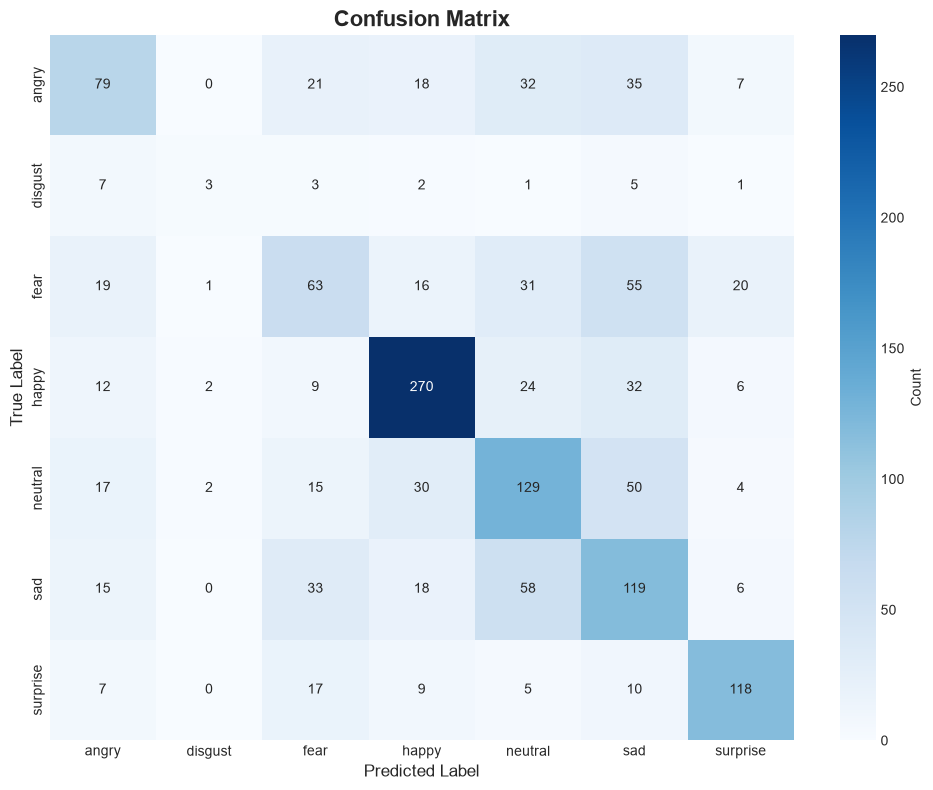


MODEL SAVED
- Model: models/emotion_dnn_model.keras
- Label Encoder: models/label_encoder.pkl


In [7]:
# Final Evaluation
print("="*60)
print("FINAL EVALUATION")
print("="*60)

# Test set evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss:     {test_loss:.4f}")

# Training set evaluation
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"\nTrain Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Train Loss:     {train_loss:.4f}")

# Detailed classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=emotions))

# Confusion Matrix
print("="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=emotions, yticklabels=emotions,
           cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Save model
model.save('models/emotion_dnn_model.keras')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

print("\n" + "="*60)
print("MODEL SAVED")
print("="*60)
print("- Model: models/emotion_dnn_model.keras")
print("- Label Encoder: models/label_encoder.pkl")

## 8. Training History Visualization

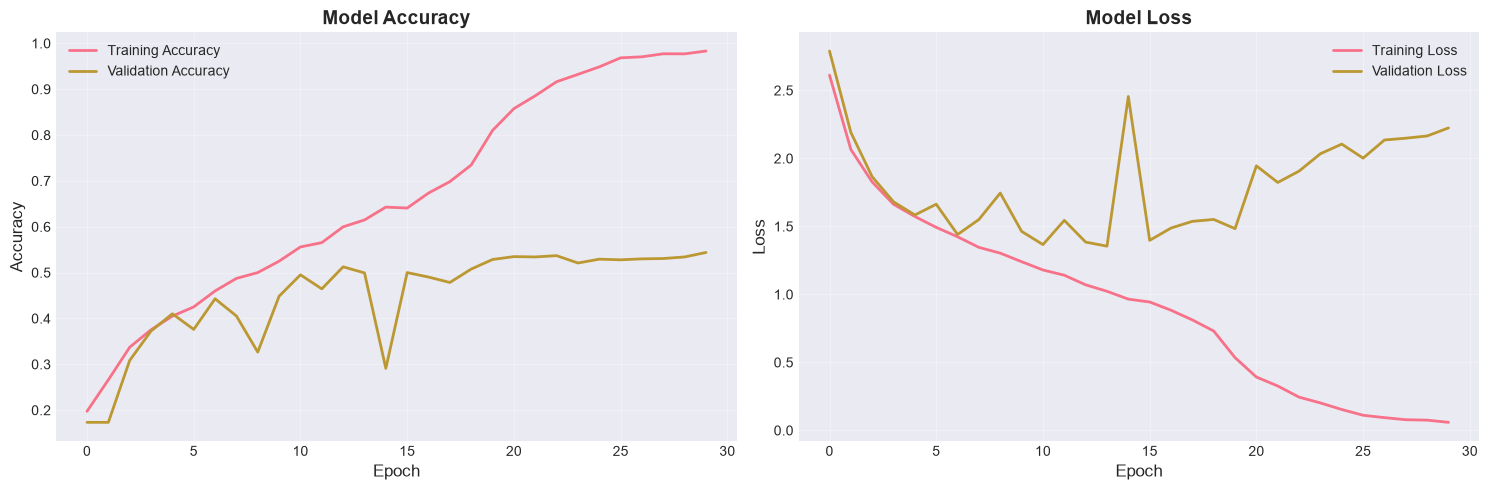


Training completed after 30 epochs


In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining completed after {len(history.history['accuracy'])} epochs")

## 9. Sample Predictions

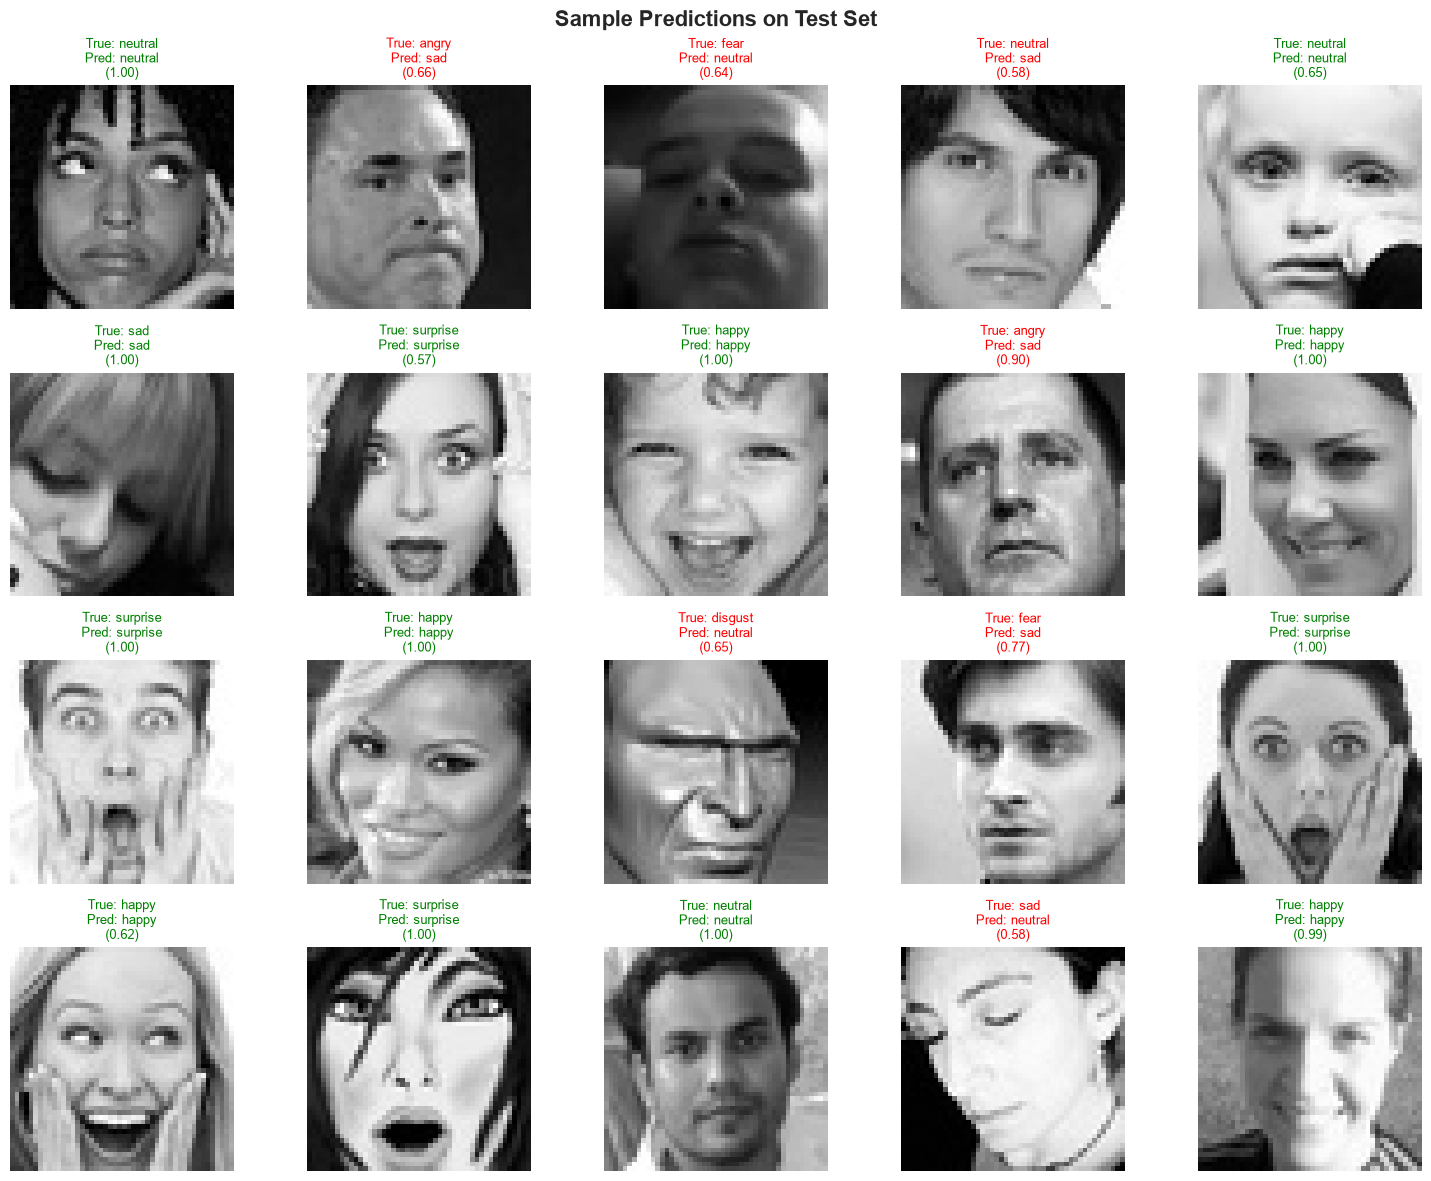


PER-CLASS ACCURACY
angry     : 0.4115 (41.15%) - 192 samples
disgust   : 0.1364 (13.64%) - 22 samples
fear      : 0.3073 (30.73%) - 205 samples
happy     : 0.7606 (76.06%) - 355 samples
neutral   : 0.5223 (52.23%) - 247 samples
sad       : 0.4779 (47.79%) - 249 samples
surprise  : 0.7108 (71.08%) - 166 samples


In [9]:
# Visualize sample predictions
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Sample Predictions on Test Set', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flatten()):
    if idx < 20:  # Show 20 samples
        # Get random test sample
        sample_idx = np.random.randint(0, len(X_test))
        
        # Get image and predictions
        img = X_test[sample_idx].reshape(48, 48)
        true_label = emotions[y_true_classes[sample_idx]]
        pred_label = emotions[y_pred_classes[sample_idx]]
        confidence = y_pred[sample_idx].max()
        
        # Display
        ax.imshow(img, cmap='gray')
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}\n({confidence:.2f})', 
                    color=color, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\n" + "="*60)
print("PER-CLASS ACCURACY")
print("="*60)

for i, emotion in enumerate(emotions):
    mask = y_true_classes == i
    if mask.sum() > 0:
        class_acc = (y_pred_classes[mask] == y_true_classes[mask]).mean()
        print(f"{emotion:10s}: {class_acc:.4f} ({class_acc*100:.2f}%) - {mask.sum()} samples")

## Summary

This notebook demonstrates a complete emotion detection pipeline:

1. **Dataset**: 2,649 images across 4 emotion classes
2. **Model**: Deep CNN with BatchNormalization and Dropout
3. **Training**: Early stopping and learning rate scheduling
4. **Evaluation**: Accuracy, classification report, and confusion matrix

**Next Steps**:
- Try different architectures (ResNet, EfficientNet)
- Data augmentation to improve performance
- Hyperparameter tuning
- Deploy model for real-time inference